Successfully loaded a01
Sampling rate: 100 Hz
Duration: 492.8 minutes (2957000 samples)
Number of 1-minute annotations: 489
Sample labels (first 10): ['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


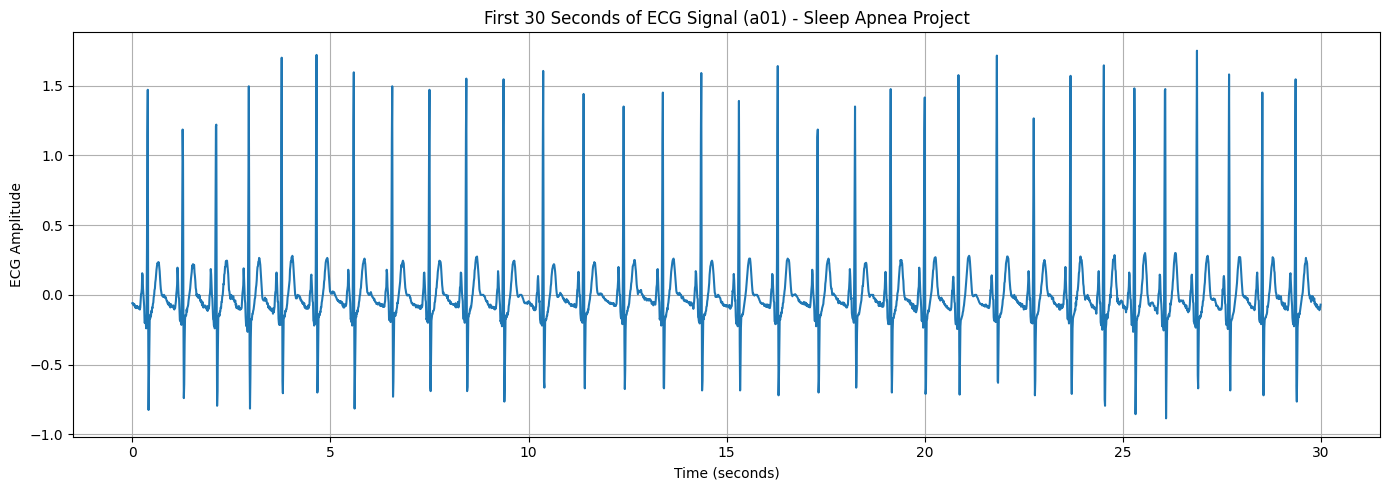

In [7]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os

# ⚠️ UPDATE THIS PATH TO WHERE YOU UNZIPPED THE APNEA-ECG DATASET (FOLDER, NOT .zip)
# Examples:
# "D:/datasets/apnea-ecg/"
# r"C:\Users\YourName\Downloads\apnea-ecg\"
# Or if you placed it inside the project: "./data/apnea-ecg/"

DATA_PATH = r"C:\Users\siddh\Downloads\apnea-ecg-database-1.0.0\apnea-ecg-database-1.0.0"   # ← CHANGE THIS TO YOUR ACTUAL PATH

# Test loading record 'a01' (first training recording)
record_name = os.path.join(DATA_PATH, "a01")

record = wfdb.rdrecord(record_name)
annotation = wfdb.rdann(record_name, 'apn')

ecg = record.p_signal.flatten()  # Single-lead ECG
fs = record.fs                   # Sampling frequency (should be 100 Hz)

print(f"Successfully loaded {record.record_name}")
print(f"Sampling rate: {fs} Hz")
print(f"Duration: {len(ecg)/fs/60:.1f} minutes ({len(ecg)} samples)")
print(f"Number of 1-minute annotations: {len(annotation.sample)}")
print(f"Sample labels (first 10): {annotation.symbol[:10]}")  # N = normal, A = apnea

# Plot first 30 seconds for visual check
samples_30s = int(fs * 30)
time_seconds = np.arange(samples_30s) / fs

plt.figure(figsize=(14, 5))
plt.plot(time_seconds, ecg[:samples_30s])
plt.title("First 30 Seconds of ECG Signal (a01) - Sleep Apnea Project")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()